In [1]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt


from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import *
from src.dataPreProcessing import replace_nan

# if variables are changed on the fly 
from reloading import reloading
from tqdm.notebook import tqdm

In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

## Simulate data

An example ground truth connectivity matrix `A`

In [3]:
np.random.seed(3465)
n_neur=30
A = np.random.choice([0,0.5,0.85], p=[0.9,0.03,0.07], size=(n_neur,n_neur)) ### A is not the adjacency matrix in the typical sense
A = 0.5*(A)
A[0:10,0:10] =np.zeros((10,10))
for n, i in enumerate(A):
    A[n][n]=1
for n, i in enumerate(A):
    A[n]=A[n]/np.sum(A[n])
A.shape

(30, 30)

Text(0.5, 1.0, 'GT')

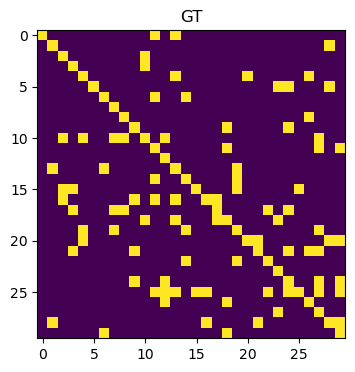

In [4]:
plt.figure(figsize=(4,4))
plt.imshow(A.T!=0)
plt.title('GT')

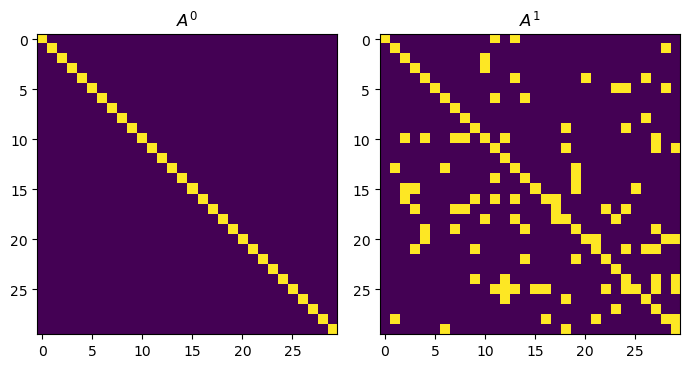

In [5]:
fig,ax = plt.subplots(1,2,figsize=(7,4))
ax[0].imshow(np.eye(30))
ax[0].set_title('$A^{0}$')
ax[1].imshow(A.T!=0)
ax[1].set_title('$A^{1}$')

plt.tight_layout()

In [6]:
def continuous_noise_fun(num, l=5000):
    xx = np.linspace(0,500,l)
    noise = np.zeros((num,l))
    for i in range(num):
        a = 2*np.random.normal(0,0.25,size=6)
        c = 500*(np.random.random(size=6))
        s = 1+100*(np.random.random(size=6))
        yy = 0*xx
        for j in range(6):
            yy = yy + a[j]*np.exp(-(xx-c[j])**2/s[j]) 
        noise[i] = yy
    return noise 
np.random.seed(13)

noise = continuous_noise_fun(num=n_neur, l=5000)

In [7]:
noise.shape

(30, 5000)

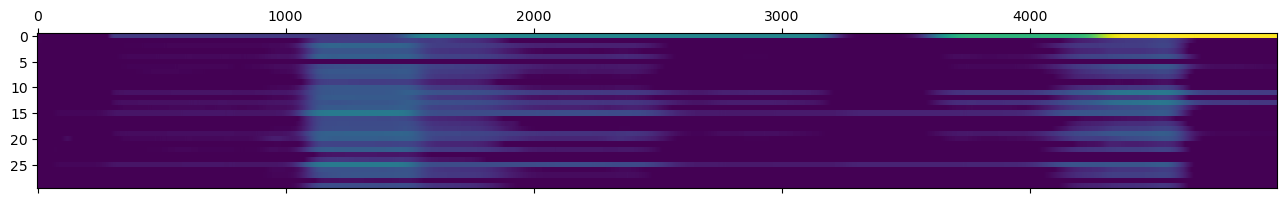

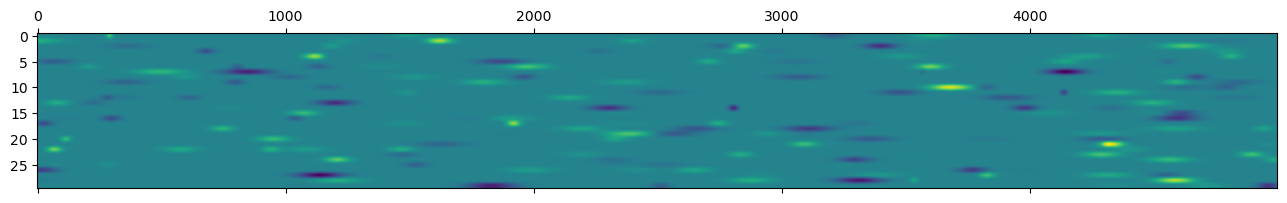

In [8]:
X = np.zeros([A.shape[0],5000]).T
X[0] = np.random.randn(A.shape[0])
for i, row in enumerate(X[:-1]):
    X[i+1] = A @ X[i] + 0.05*np.random.normal(0,0.25,A.shape[0]) + noise[:,i]
X=X.T
plt.matshow(X, aspect='auto',vmin=0)
plt.matshow(noise, aspect='auto', interpolation=None)

## Analysis

In [9]:
N_PASTS, n_lags, n_perm = np.arange(1, 8, 1), 1, 1000
alpha, beta = 0.01, 0.001

In [ ]:
%%time
metrics = np.zeros((7,4))
infs = []
for i, n in enumerate(N_PASTS):
    print(f'{n} pasts')
    gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = 'fcgc')
    
    gcstar.fit(X, verbose = 1)
    
    infs.append(gcstar.get_connectivity_matrix(simulation=True))
    gcstar.plot_extended_connectivity_matrix()
    gcstar.compute_confusion_matrix(A, simulation = True)
    metrics[i] =  gcstar.compute_metrics()

INFO:src.d_CSL:Starting correlation_func
INFO:src.d_CSL:Starting inv_correlation_func
INFO:src.d_CSL:Waiting for correlation_func and inv_correlation_func to complete


1 pasts


C:\Users\sadiq\Documents\GC-extension\examples\..\src\d_CSL.py:32: NumbaExperimentalFeatureWarning: Use of isinstance() detected. This is an experimental feature.
  corr_1 = np.corrcoef(x, y)[1, 0]
INFO:src.d_CSL:Step 1/1800 (0.06% complete)
INFO:src.d_CSL:Step 1/1800 (0.06% complete)
INFO:src.d_CSL:Step 2/1800 (0.11% complete)
INFO:src.d_CSL:Step 3/1800 (0.17% complete)
INFO:src.d_CSL:Step 4/1800 (0.22% complete)
INFO:src.d_CSL:Step 5/1800 (0.28% complete)
INFO:src.d_CSL:Step 6/1800 (0.33% complete)
INFO:src.d_CSL:Step 7/1800 (0.39% complete)
INFO:src.d_CSL:Step 8/1800 (0.44% complete)
INFO:src.d_CSL:Step 9/1800 (0.50% complete)
INFO:src.d_CSL:Step 10/1800 (0.56% complete)
INFO:src.d_CSL:Step 11/1800 (0.61% complete)
INFO:src.d_CSL:Step 12/1800 (0.67% complete)
INFO:src.d_CSL:Step 13/1800 (0.72% complete)
INFO:src.d_CSL:Step 14/1800 (0.78% complete)
INFO:src.d_CSL:Step 15/1800 (0.83% complete)
INFO:src.d_CSL:Step 16/1800 (0.89% complete)
INFO:src.d_CSL:Step 17/1800 (0.94% complete)
IN

INFO:src.d_CSL:Step 167/1800 (9.28% complete)
INFO:src.d_CSL:Step 168/1800 (9.33% complete)
INFO:src.d_CSL:Step 169/1800 (9.39% complete)
INFO:src.d_CSL:Step 170/1800 (9.44% complete)
INFO:src.d_CSL:Step 171/1800 (9.50% complete)
INFO:src.d_CSL:Step 172/1800 (9.56% complete)
INFO:src.d_CSL:Step 173/1800 (9.61% complete)
INFO:src.d_CSL:Step 174/1800 (9.67% complete)
INFO:src.d_CSL:Step 175/1800 (9.72% complete)
INFO:src.d_CSL:Step 11/1800 (0.61% complete)
INFO:src.d_CSL:Step 176/1800 (9.78% complete)
INFO:src.d_CSL:Step 177/1800 (9.83% complete)
INFO:src.d_CSL:Step 178/1800 (9.89% complete)
INFO:src.d_CSL:Step 179/1800 (9.94% complete)
INFO:src.d_CSL:Step 180/1800 (10.00% complete)
INFO:src.d_CSL:Step 181/1800 (10.06% complete)
INFO:src.d_CSL:Step 182/1800 (10.11% complete)
INFO:src.d_CSL:Step 183/1800 (10.17% complete)
INFO:src.d_CSL:Step 184/1800 (10.22% complete)
INFO:src.d_CSL:Step 185/1800 (10.28% complete)
INFO:src.d_CSL:Step 186/1800 (10.33% complete)
INFO:src.d_CSL:Step 187/1800

INFO:src.d_CSL:Step 333/1800 (18.50% complete)
INFO:src.d_CSL:Step 334/1800 (18.56% complete)
INFO:src.d_CSL:Step 335/1800 (18.61% complete)
INFO:src.d_CSL:Step 336/1800 (18.67% complete)
INFO:src.d_CSL:Step 337/1800 (18.72% complete)
INFO:src.d_CSL:Step 338/1800 (18.78% complete)
INFO:src.d_CSL:Step 339/1800 (18.83% complete)
INFO:src.d_CSL:Step 340/1800 (18.89% complete)
INFO:src.d_CSL:Step 341/1800 (18.94% complete)
INFO:src.d_CSL:Step 342/1800 (19.00% complete)
INFO:src.d_CSL:Step 343/1800 (19.06% complete)
INFO:src.d_CSL:Step 344/1800 (19.11% complete)
INFO:src.d_CSL:Step 345/1800 (19.17% complete)
INFO:src.d_CSL:Step 346/1800 (19.22% complete)
INFO:src.d_CSL:Step 347/1800 (19.28% complete)
INFO:src.d_CSL:Step 21/1800 (1.17% complete)
INFO:src.d_CSL:Step 348/1800 (19.33% complete)
INFO:src.d_CSL:Step 349/1800 (19.39% complete)
INFO:src.d_CSL:Step 350/1800 (19.44% complete)
INFO:src.d_CSL:Step 351/1800 (19.50% complete)
INFO:src.d_CSL:Step 352/1800 (19.56% complete)
INFO:src.d_CSL:

...

INFO:src.d_CSL:Step 3/2700 (0.11% complete)
INFO:src.d_CSL:Step 4/2700 (0.15% complete)
INFO:src.d_CSL:Step 5/2700 (0.19% complete)
INFO:src.d_CSL:Step 6/2700 (0.22% complete)
INFO:src.d_CSL:Step 7/2700 (0.26% complete)
INFO:src.d_CSL:Step 8/2700 (0.30% complete)
INFO:src.d_CSL:Step 9/2700 (0.33% complete)
INFO:src.d_CSL:Step 10/2700 (0.37% complete)
INFO:src.d_CSL:Step 11/2700 (0.41% complete)
INFO:src.d_CSL:Step 12/2700 (0.44% complete)
INFO:src.d_CSL:Step 13/2700 (0.48% complete)
INFO:src.d_CSL:Step 14/2700 (0.52% complete)
INFO:src.d_CSL:Step 15/2700 (0.56% complete)
INFO:src.d_CSL:Step 16/2700 (0.59% complete)
INFO:src.d_CSL:Step 17/2700 (0.63% complete)
INFO:src.d_CSL:Step 18/2700 (0.67% complete)
INFO:src.d_CSL:Step 1/2700 (0.04% complete)
INFO:src.d_CSL:Step 19/2700 (0.70% complete)
INFO:src.d_CSL:Step 20/2700 (0.74% complete)
INFO:src.d_CSL:Step 21/2700 (0.78% complete)
INFO:src.d_CSL:Step 22/2700 (0.81% complete)
INFO:src.d_CSL:Step 23/2700 (0.85% complete)
INFO:src.d_CSL:Ste

INFO:src.d_CSL:Step 176/2700 (6.52% complete)
INFO:src.d_CSL:Step 177/2700 (6.56% complete)
INFO:src.d_CSL:Step 178/2700 (6.59% complete)
INFO:src.d_CSL:Step 179/2700 (6.63% complete)
INFO:src.d_CSL:Step 9/2700 (0.33% complete)
INFO:src.d_CSL:Step 180/2700 (6.67% complete)
INFO:src.d_CSL:Step 181/2700 (6.70% complete)
INFO:src.d_CSL:Step 182/2700 (6.74% complete)
INFO:src.d_CSL:Step 183/2700 (6.78% complete)
INFO:src.d_CSL:Step 184/2700 (6.81% complete)
INFO:src.d_CSL:Step 185/2700 (6.85% complete)
INFO:src.d_CSL:Step 186/2700 (6.89% complete)
INFO:src.d_CSL:Step 187/2700 (6.93% complete)
INFO:src.d_CSL:Step 188/2700 (6.96% complete)
INFO:src.d_CSL:Step 189/2700 (7.00% complete)
INFO:src.d_CSL:Step 190/2700 (7.04% complete)
INFO:src.d_CSL:Step 191/2700 (7.07% complete)
INFO:src.d_CSL:Step 192/2700 (7.11% complete)
INFO:src.d_CSL:Step 193/2700 (7.15% complete)
INFO:src.d_CSL:Step 194/2700 (7.19% complete)
INFO:src.d_CSL:Step 195/2700 (7.22% complete)
INFO:src.d_CSL:Step 196/2700 (7.26% 

INFO:src.d_CSL:Step 345/2700 (12.78% complete)
INFO:src.d_CSL:Step 346/2700 (12.81% complete)
INFO:src.d_CSL:Step 17/2700 (0.63% complete)
INFO:src.d_CSL:Step 347/2700 (12.85% complete)
INFO:src.d_CSL:Step 348/2700 (12.89% complete)
INFO:src.d_CSL:Step 349/2700 (12.93% complete)
INFO:src.d_CSL:Step 350/2700 (12.96% complete)
INFO:src.d_CSL:Step 351/2700 (13.00% complete)
INFO:src.d_CSL:Step 352/2700 (13.04% complete)
INFO:src.d_CSL:Step 353/2700 (13.07% complete)
INFO:src.d_CSL:Step 354/2700 (13.11% complete)
INFO:src.d_CSL:Step 355/2700 (13.15% complete)
INFO:src.d_CSL:Step 356/2700 (13.19% complete)
INFO:src.d_CSL:Step 357/2700 (13.22% complete)
INFO:src.d_CSL:Step 358/2700 (13.26% complete)
INFO:src.d_CSL:Step 359/2700 (13.30% complete)
INFO:src.d_CSL:Step 360/2700 (13.33% complete)
INFO:src.d_CSL:Step 361/2700 (13.37% complete)
INFO:src.d_CSL:Step 362/2700 (13.41% complete)
INFO:src.d_CSL:Step 363/2700 (13.44% complete)
INFO:src.d_CSL:Step 364/2700 (13.48% complete)
INFO:src.d_CSL:

INFO:src.d_CSL:Step 511/2700 (18.93% complete)
INFO:src.d_CSL:Step 512/2700 (18.96% complete)
INFO:src.d_CSL:Step 513/2700 (19.00% complete)
INFO:src.d_CSL:Step 514/2700 (19.04% complete)
INFO:src.d_CSL:Step 515/2700 (19.07% complete)
INFO:src.d_CSL:Step 516/2700 (19.11% complete)
INFO:src.d_CSL:Step 517/2700 (19.15% complete)
INFO:src.d_CSL:Step 518/2700 (19.19% complete)
INFO:src.d_CSL:Step 519/2700 (19.22% complete)
INFO:src.d_CSL:Step 520/2700 (19.26% complete)
INFO:src.d_CSL:Step 521/2700 (19.30% complete)
INFO:src.d_CSL:Step 522/2700 (19.33% complete)
INFO:src.d_CSL:Step 523/2700 (19.37% complete)
INFO:src.d_CSL:Step 524/2700 (19.41% complete)
INFO:src.d_CSL:Step 525/2700 (19.44% complete)
INFO:src.d_CSL:Step 526/2700 (19.48% complete)
INFO:src.d_CSL:Step 26/2700 (0.96% complete)
INFO:src.d_CSL:Step 527/2700 (19.52% complete)
INFO:src.d_CSL:Step 528/2700 (19.56% complete)
INFO:src.d_CSL:Step 529/2700 (19.59% complete)
INFO:src.d_CSL:Step 530/2700 (19.63% complete)
INFO:src.d_CSL:

INFO:src.d_CSL:Step 678/2700 (25.11% complete)
INFO:src.d_CSL:Step 679/2700 (25.15% complete)
INFO:src.d_CSL:Step 680/2700 (25.19% complete)
INFO:src.d_CSL:Step 681/2700 (25.22% complete)
INFO:src.d_CSL:Step 682/2700 (25.26% complete)
INFO:src.d_CSL:Step 683/2700 (25.30% complete)
INFO:src.d_CSL:Step 684/2700 (25.33% complete)
INFO:src.d_CSL:Step 34/2700 (1.26% complete)
INFO:src.d_CSL:Step 685/2700 (25.37% complete)
INFO:src.d_CSL:Step 686/2700 (25.41% complete)
INFO:src.d_CSL:Step 687/2700 (25.44% complete)
INFO:src.d_CSL:Step 688/2700 (25.48% complete)
INFO:src.d_CSL:Step 689/2700 (25.52% complete)
INFO:src.d_CSL:Step 690/2700 (25.56% complete)
INFO:src.d_CSL:Step 691/2700 (25.59% complete)
INFO:src.d_CSL:Step 692/2700 (25.63% complete)
INFO:src.d_CSL:Step 693/2700 (25.67% complete)
INFO:src.d_CSL:Step 694/2700 (25.70% complete)
INFO:src.d_CSL:Step 695/2700 (25.74% complete)
INFO:src.d_CSL:Step 696/2700 (25.78% complete)
INFO:src.d_CSL:Step 697/2700 (25.81% complete)
INFO:src.d_CSL:

In [ ]:
metrics

In [ ]:
labels = ['Acc', 'Prec', 'Rec', 'FPR']
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(metrics.shape[1]):
    ax[i].plot(metrics[:, i], marker = '.', label = labels[i], c = 'blue')
    ax[i].set_xticks(np.arange(metrics.shape[0]), list(np.arange(1, 8, 1)))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation = 180)
    ax[i].set_title(f'{labels[i]}')
plt.tight_layout()

In [ ]:
def mat_func(A,inf):
    return 40*np.logical_and(A!=0,inf!=0) + 30*np.logical_and(A==0,inf!=0) + 20*np.logical_and(A!=0,inf==0)+10*np.logical_and(A==0,inf==0)

In [ ]:
for i, el in enumerate(infs):
    plt.figure(figsize = (5,5))
    plt.imshow(mat_func(A.T, el))
    plt.title(f'{i+1} pasts')

In [ ]:
def confusion_matrix(inferred, A):
    TP_inf = np.sum(np.logical_and(A != 0,inferred!=0))
    FN_inf = np.sum(np.logical_and(A != 0,inferred==0))
    FP_inf = np.sum(np.logical_and(A == 0,inferred!=0))
    TN_inf = np.sum(np.logical_and(A == 0,inferred==0))
    return np.array([[TP_inf,FN_inf],
                     [FP_inf,TN_inf]])

In [ ]:
%matplotlib inline
import seaborn as sns
fig,axes = plt.subplots(7, 1, figsize=(4,20))
for i, ax in enumerate(axes):
    conf = confusion_matrix(infs[i], A.T)
    print(conf)
    g1 = sns.heatmap(conf, annot=True, ax=ax)

In [4]:
import numpy as np
from numba import jit, njit

@jit(nopython=True)
def prep_data_(X, nn):
    if nn == 0:
        return X
    X_ = X[:, nn:]
    for i in range(nn):
        idx1, idx2 = nn - 1 - i, -i - 1
        X_ = np.column_stack((X_, X[:, idx1:idx2]))
    return X_


@jit(nopython=True)
def get_cond_set_(X, n_past, i, j):
    data = X.copy()
    n_neur = data.shape[0]
    shifted_data = prep_data_(data, n_past)
    i_ = i % n_neur

    x_idx = np.array([i_ + a * n_neur for a in range(i // n_neur)], dtype=np.int64)
    to_delete = np.concatenate((x_idx, np.array([i, j])))   #  , dtype=np.int64

    result = np.empty((shifted_data.shape[0] - len(to_delete), shifted_data.shape[1]), dtype=shifted_data.dtype)
    k = 0

    for row in range(shifted_data.shape[0]):
        if row not in to_delete:
            result[k] = shifted_data[row]
            k += 1

    return result



In [5]:
Y = np.arange(60).reshape(3,20)
Y

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19],
       [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39],
       [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55,
        56, 57, 58, 59]])

In [6]:
get_cond_set_(Y, 5, 12, 2)

ValueError: negative dimensions not allowed